# F recovery vs. permutation distance from F_viab -- selectivity phase only (J = 0)

**Question.** The selectivity ground truth `F_sel` here is built by permuting the amino-acid
rows of the real AAV9 `F_viab` -- a coherent relabeling of "which amino acid gets which
position-profile shape", the same mechanic `initialize_weights.initialize_indep_weights` uses
(minus its added noise term). Does a `ProfileMLP` trained on the resulting NGS-measured
selectivity log enrichment (`target2`) recover that permuted `F_sel` more or less faithfully
depending on how correlated it happens to land with `F_viab`?

**Design.**
- Ground truth for viability: the real AAV9 `F_viab` (`load_F_viab_aav9_mlp`). `J_viab` is an
  explicit all-zero tensor for this first pass -- no epistasis, viability is purely additive
  (see the project's `CLAUDE.md`: "F_viab/J_viab=0 (no J in a first place)").
- Ground truth for selectivity: 30 independent `F_sel` matrices, each `F_viab[sigma_k, :]` for a
  different random permutation `sigma_k` of the 20 amino acids (`jax.random.permutation`, one of
  30 independent `jax` keys, no added noise). `J_sel` is zero too, for the same reason as
  `J_viab` -- nothing in this notebook has any epistatic term. Section 2b visualizes what each
  `sigma_k` actually does to the amino-acid identity, before any simulation/training happens.
- ONE fixed pool of `N=20,000` random 7-mers and ONE fixed train/val/test split, reused
  identically across all 30 permutations -- only `F_sel` changes between runs, so any
  difference in predictive/recovery quality is attributable to `F_sel`, not to pool composition
  (same convention as `MLP_viability_noise_denoising20K.ipynb`'s `noise_viab` sweep).
- For each of the 30 `F_sel`: simulate one directed-evolution round (`ProtocolV3`), build the
  NGS-measured selectivity log enrichment `target2 = log((lambda3p + eps) / (lambda2p + eps))`,
  train a fresh `ProfileMLP` on it, and:
  1. measure `pearson(prediction, target2)` on the held-out test fold,
  2. recover an effective `F_sel_hat` from the trained MLP via a single-mutant scan
     (`extract_effective_F` -- `J` is skipped entirely here since the ground truth has none),
  3. compare `F_sel_hat` against the TRUE `F_sel` used to generate that run's data.

Everything is plotted against `r(F_sel, F_viab)` -- the Pearson correlation each permutation
happens to achieve with the real viability profile -- to see whether recovery degrades, holds
up, or is unaffected as `F_sel` drifts further from `F_viab`.


## 0. Setup

In [16]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.


In [17]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth `F_viab` (`J_viab = 0` for this first pass)

Loaded via `load_F_viab_aav9_mlp` -- the real AAV9 profile, exported by
`AAV9_profile_model.ipynb`. `J_viab` is an explicit all-zero `(7, 7, 20, 20)` tensor: this first
pass of the analysis studies the additive (profile-only) term exclusively -- no epistasis
anywhere in this notebook (`J_viab` AND `J_sel` are both zero).


F_viab shape: (20, 7)   J_zero shape: (7, 7, 20, 20)


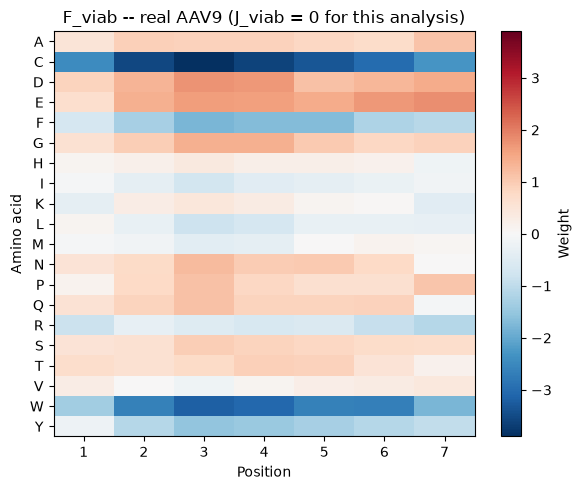

In [18]:
F_viab = load_F_viab_aav9_mlp()
J_zero = jnp.zeros((NUM_POSITIONS, NUM_POSITIONS, NUM_AMINO_ACIDS, NUM_AMINO_ACIDS))

print(f"F_viab shape: {F_viab.shape}   J_zero shape: {J_zero.shape}")
_ = plot_teacher_weights(F_viab, title="F_viab -- real AAV9 (J_viab = 0 for this analysis)")
plt.show()


## 2. Thirty permuted `F_sel` matrices -- one per `jax` key

Each `F_sel_k = F_viab[sigma_k, :]` for an independent random permutation `sigma_k` of the 20
amino acids (`jax.random.permutation`, no added noise -- a pure relabeling, same mechanic as
`initialize_weights.initialize_indep_weights` but without its default Gaussian noise term).
`r_gt[k] = pearson(F_viab, F_sel_k)` is the achieved ground-truth correlation for that
permutation -- with 20! possible permutations this lands close to 0 almost always, occasionally
a bit further out; unlike `initialize_correlated_weights`, this is NOT a targeted correlation
level, just whatever a given random relabeling happens to produce.


perm 0: sigma=[16 10  0  8  2 11  4  1  7 19 13 17 14 15  9  5 18  3  6 12]   r(F_sel, F_viab) = +0.0216
perm 1: sigma=[ 0  3  9  5 18 14  1  8 17  4 13  6  2 19 15 11 10 16 12  7]   r(F_sel, F_viab) = -0.0464
perm 2: sigma=[16  7  4 17 18 12  3 10  1 13  6 19 14 11  0  2 15  5  9  8]   r(F_sel, F_viab) = +0.1698
perm 3: sigma=[12 11 16  8 14 10  2  9 18  1 15 19  7  4  3  5  6  0 13 17]   r(F_sel, F_viab) = -0.1105
perm 4: sigma=[ 2  5  4  9  6 14 11 17  8 16 10  0 18  7  1 15 12 19  3 13]   r(F_sel, F_viab) = -0.2909
perm 5: sigma=[11  3 14  6 19  8  7 15 17  4 13 12  2 16  9 18  5 10  1  0]   r(F_sel, F_viab) = +0.1796
perm 6: sigma=[ 6  7 17 16  3 18  5  0 12  2  8 15  9 14  1 13 10  4 19 11]   r(F_sel, F_viab) = +0.0406
perm 7: sigma=[ 0 16 11  7  5 15  9  2 12 19 17 18 10  4  8  1 13 14  3  6]   r(F_sel, F_viab) = -0.3531
perm 8: sigma=[ 8  6  7  0 11  4 14 17 16  5 10 18  3  2 19  1  9 13 15 12]   r(F_sel, F_viab) = -0.2405
perm 9: sigma=[ 4  0 12  2 11 15 13 16  8 14  5  6  3 1

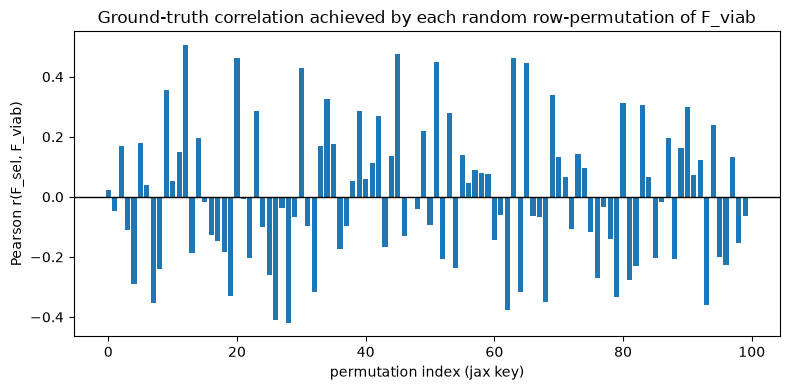

In [56]:
N_PERM = 100
keys = jax.random.split(jax.random.key(0), N_PERM)

F_sel_list, sigma_list, r_gt_list = [], [], []
for k, key in enumerate(keys):
    sigma = jax.random.permutation(key, NUM_AMINO_ACIDS)
    F_sel_k = F_viab[sigma, :]
    r_gt = pearson(np.asarray(F_viab).ravel(), np.asarray(F_sel_k).ravel())

    F_sel_list.append(F_sel_k)
    sigma_list.append(np.asarray(sigma))
    r_gt_list.append(r_gt)
    print(f"perm {k}: sigma={np.asarray(sigma)}   r(F_sel, F_viab) = {r_gt:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(N_PERM), r_gt_list, color="tab:blue")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("permutation index (jax key)")
ax.set_ylabel("Pearson r(F_sel, F_viab)")
ax.set_title("Ground-truth correlation achieved by each random row-permutation of F_viab")
fig.tight_layout()
plt.show()


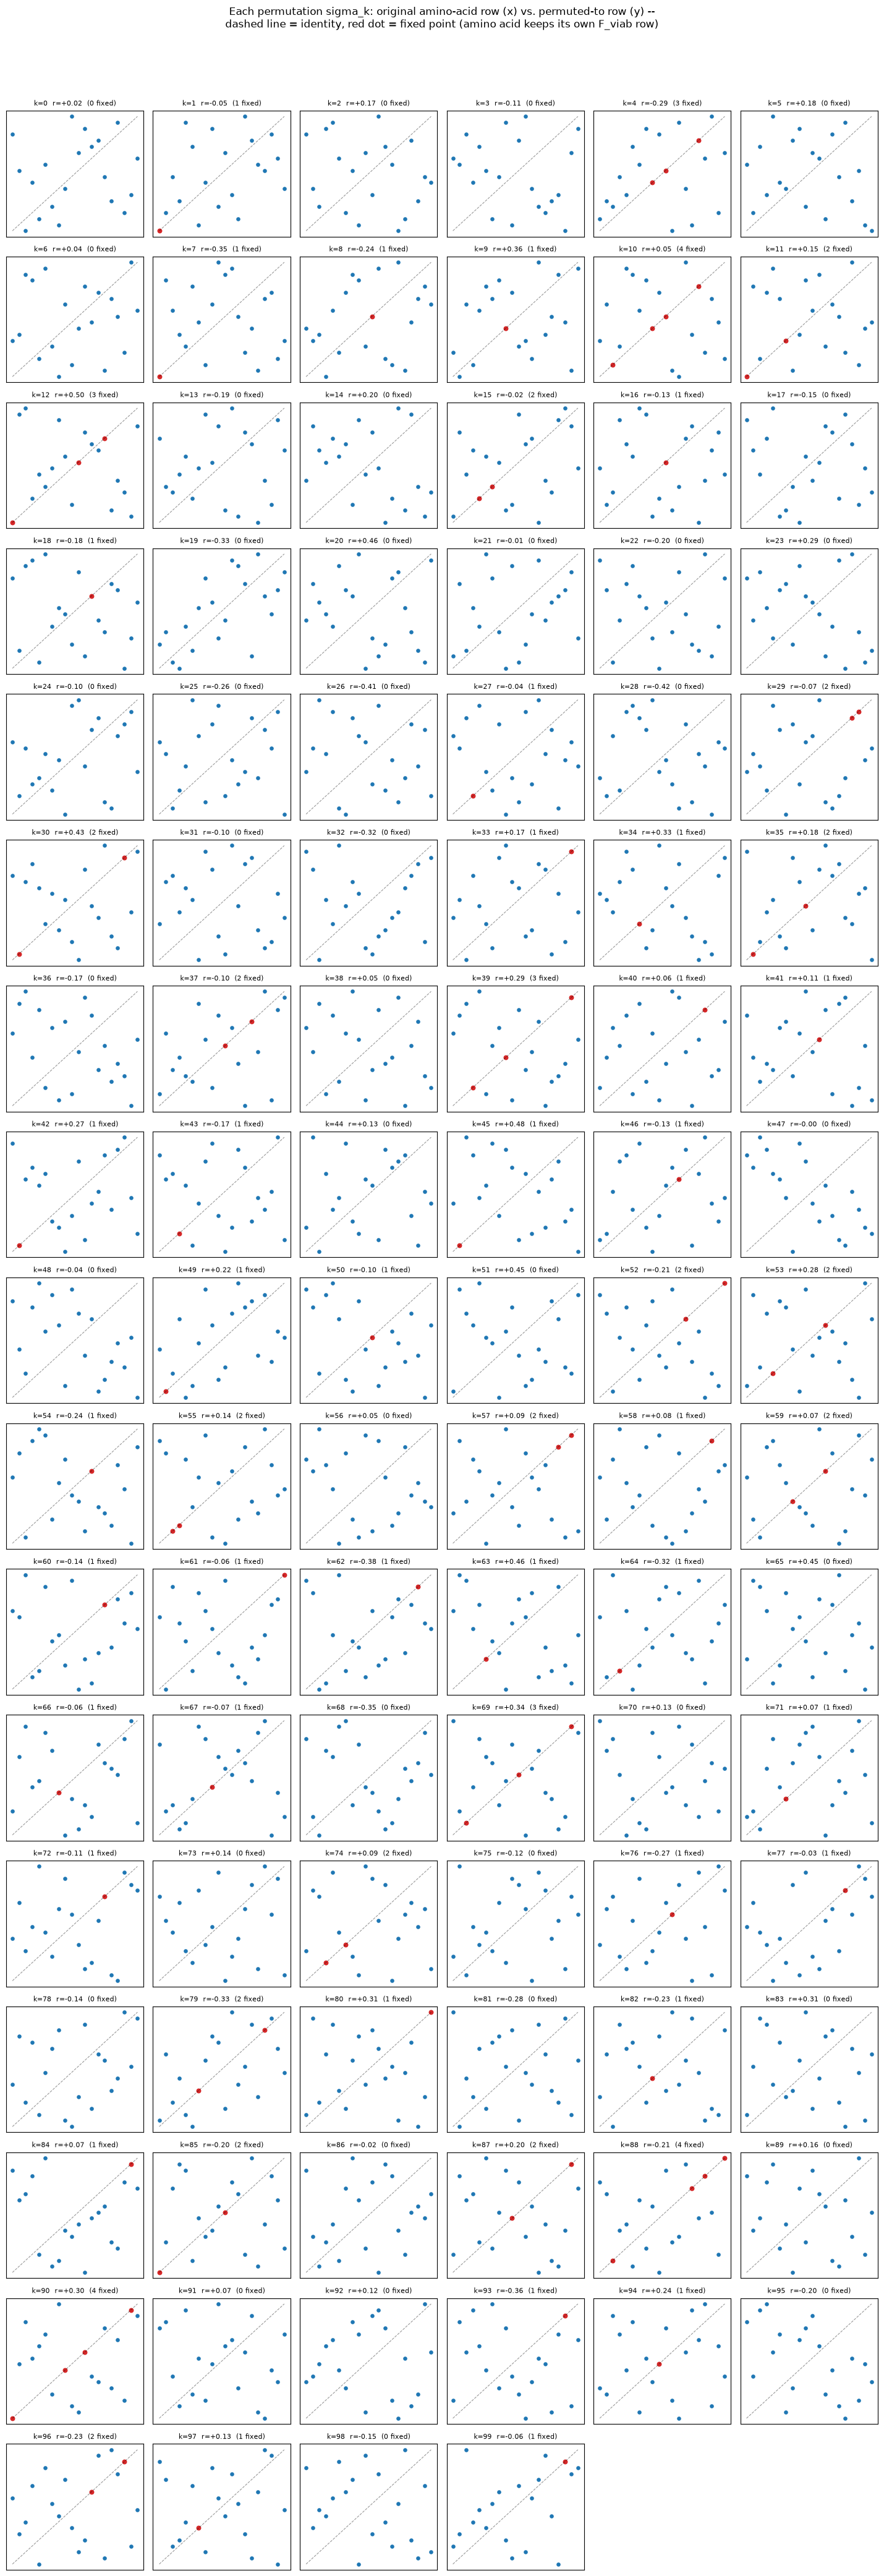

In [57]:
ncols = 6
nrows = int(np.ceil(N_PERM / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.4 * nrows), squeeze=False)

for k in range(N_PERM):
    ax       = axes[k // ncols, k % ncols]
    sigma_k  = sigma_list[k]
    is_fixed = sigma_k == aa_index

    ax.plot([0, NUM_AMINO_ACIDS - 1], [0, NUM_AMINO_ACIDS - 1], "k--", lw=0.8, alpha=0.4)
    ax.scatter(aa_index[~is_fixed], sigma_k[~is_fixed], s=14, color="tab:blue")
    ax.scatter(aa_index[is_fixed],  sigma_k[is_fixed],  s=22, color="tab:red")
    ax.set_title(f"k={k}  r={r_gt_list[k]:+.2f}  ({int(is_fixed.sum())} fixed)", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

for k in range(N_PERM, nrows * ncols):
    axes[k // ncols, k % ncols].axis("off")

fig.suptitle("Each permutation sigma_k: original amino-acid row (x) vs. permuted-to row (y) --\n"
             "dashed line = identity, red dot = fixed point (amino acid keeps its own F_viab row)",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


## 3. Fixed sequence pool + train/val/test split

ONE pool of `N=20,000` random 7-mers and ONE 50/50 train/test split (`idx_train`/`idx_test`),
built ONCE and reused identically for every one of the 30 permutations below -- same convention
as `MLP_viability_noise_denoising20K.ipynb`.


In [58]:
key_pool = jax.random.key(1)
N = 20_000
sequences = jax.random.randint(key_pool, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

seq_matrix = np.asarray(sequences)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(N, -1)

idx_train, idx_test  = train_test_split(np.arange(N), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]

print(f"sequences: {N:,}   X_train_full: {X_train_full.shape}   X_test: {X_test.shape}")


sequences: 20,000   X_train_full: (10000, 140)   X_test: (10000, 140)


## 4. Model + training utilities

Same `ProfileMLP` / `train_profile_mlp` recipe as the sibling `selectivity_weight_regimes`
notebooks (Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head;
warmup-cosine-decay AdamW; early stopping on val MSE).


In [59]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar predicted log enrichment. Identical to the sibling
    notebooks' ProfileMLP (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [60]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [61]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs  = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


## 5. Weight recovery: single-mutant scan (`F` only -- `J` is zero everywhere in this notebook)

`extract_effective_F` -- same recipe as `MLP_for_anticorrelated_weights.ipynb` /
`AAV_MLP_weights_recovery.ipynb`'s single-mutant scan, restricted to `F` since there's no `J` to
recover here (`J_sel = 0` by construction, so recovering it would only be checking that the MLP
learned ~0 everywhere -- not informative for this first pass).


In [62]:
def extract_effective_F(model, backgrounds, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS, batch_size=8192):
    """
    Single-mutant scan against background sequences: for a background s and mutation p->a,
    M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other positions.
    Averaged over many backgrounds, F is recovered up to a global additive constant. Same
    recipe as AAV9_profile_model.ipynb / MLP_for_anticorrelated_weights.ipynb.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_log_enrichment(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    return F_flat.T.astype(np.float32)                # (A, L)


## 6. Dataset caching helper

Same filename convention as the sibling notebooks (`diversity{d0}_Tsel..._Tviab..._{label}.csv`,
gitignored derived data), with the permutation index folded into `label` so the 30 runs -- which
otherwise share the same diversity/T_sel/T_viab/noise -- don't collide on the same CSV.


In [63]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    ngs_part = "multinomial" if protocol.multinomialNGS else "nbinom"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{ngs_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_sel, label):
    """(sequence, target2=selectivity log-enrichment) dataset for this protocol's parameters."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


## 7. Sweep: simulate selectivity phase, train MLP, recover `F_sel_hat` -- for each permutation

For each of the 30 permuted `F_sel`: run `ProtocolV3.N_loop_DE(1)` on the SAME fixed pool to get
a fresh NGS-measured `target2`, train a fresh `ProfileMLP` on it (same train/val split every
time), then:
- `r_test_selectivity` = `pearson(prediction, target2)` on the held-out test fold
- `F_sel_hat` recovered via `extract_effective_F`, compared against the TRUE `F_sel` for that run
  (`r_recovery_Fsel`)
- `r_hat_Fsel_vs_Fviab` = the recovered `F_sel_hat`'s OWN correlation with `F_viab` (as opposed to
  `r_recovery_Fsel`, which compares `F_sel_hat` to the true `F_sel`) -- used in section 10 to check
  whether the MLP's recovered matrix is itself biased toward anticorrelation with `F_viab`.
- `r_naive_Fsel_vs_Fviab` = a model-free baseline for the same question: `F_sel_naive[a, l] =
  mean(target2 | seq[:, l] == a) - mean(target2)`, a raw per-(amino acid, position) marginal mean
  computed directly from the simulated NGS data, no MLP involved at all. If this ALSO drifts
  toward anticorrelation with `F_viab`, the bias lives in the data-generating pipeline (e.g. the
  `eps` pseudocount inflating `target2` when `lambda2p` -- tied to `F_viab` -- is small), not in
  the MLP specifically.


In [64]:
def naive_F_from_target(seq_matrix, target, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """
    Direct, model-free per-(amino acid, position) marginal mean of `target` across the pool --
    NO MLP, no mutant scan, just group means of the raw simulated NGS label. A cheap baseline to
    check whether a correlation pattern already exists in the data before any model sees it.
    """
    global_mean = target.mean()
    F_naive = np.full((A, L), np.nan, dtype=np.float64)
    for l in range(L):
        for a in range(A):
            mask = seq_matrix[:, l] == a
            if mask.any():
                F_naive[a, l] = target[mask].mean() - global_mean
    return F_naive


M_BACKGROUNDS = 256
rng_bg  = np.random.default_rng(0)
bg_idx  = rng_bg.choice(N, size=M_BACKGROUNDS, replace=False)
backgrounds = seq_matrix[bg_idx]

results = []
models_by_perm, preds_test_by_perm, y_test_by_perm = {}, {}, {}
F_sel_hat_by_perm, F_sel_naive_by_perm = {}, {}

for k in range(N_PERM):
    print(f"\n=== permutation {k}  (r(F_sel, F_viab) = {r_gt_list[k]:+.4f}) ===")
    F_sel_k = F_sel_list[k]

    protocol_k = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=sequences, D=1e9,
            F_viab=F_viab, J_viab=J_zero, F_sel=F_sel_k, J_sel=J_zero,
            noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
            )

    _bio_row, ngs_row = protocol_k.N_loop_DE(1)[0]
    lambda0p, lambda2p, lambda3p = (np.asarray(a) for a in ngs_row)
    eps = 1.0
    log_enr_sel_k = np.log((lambda3p + eps) / (lambda2p + eps))  # target2 -- selectivity phase

    dataset_k = build_or_load_dataset(protocol_k, sequences, log_enr_sel_k, label=f"rowpermF_k{k}")
    y_all_k = dataset_k["target2"].to_numpy()
    y_train_k, y_test_k = y_all_k[idx_train], y_all_k[idx_test]

    Xtr, ytr, Xva, yva = split_train_val(X_train_full, y_train_k, val_frac=0.15, seed=0)
    model_k, hist_k = train_profile_mlp(Xtr, ytr, Xva, yva, seed=0, verbose=False)

    pred_test_k = np.asarray(predict_log_enrichment(model_k, jnp.asarray(X_test)))
    r_test_k    = pearson(y_test_k, pred_test_k)

    F_sel_hat_k     = extract_effective_F(model_k, backgrounds)
    r_recovery_k    = pearson(np.asarray(F_sel_k).ravel(), F_sel_hat_k.ravel())
    r_hat_vs_viab_k = pearson(np.asarray(F_viab).ravel(), F_sel_hat_k.ravel())

    F_sel_naive_k = naive_F_from_target(seq_matrix, y_all_k)
    valid         = ~np.isnan(F_sel_naive_k)
    r_naive_k     = pearson(np.asarray(F_viab)[valid].ravel(), F_sel_naive_k[valid].ravel())

    print(f"  Pearson r (test, prediction vs target2)          = {r_test_k:.4f}")
    print(f"  Pearson r (F_sel_hat vs true F_sel this run)      = {r_recovery_k:.4f}")
    print(f"  Pearson r (F_sel_hat vs F_viab)                   = {r_hat_vs_viab_k:.4f}   "
          f"(true F_sel vs F_viab was {r_gt_list[k]:+.4f})")
    print(f"  Pearson r (naive raw-data marginal means vs F_viab) = {r_naive_k:.4f}")

    results.append(dict(perm_idx=k, r_gt_Fsel_vs_Fviab=r_gt_list[k],
                         r_test_selectivity=r_test_k, r_recovery_Fsel=r_recovery_k,
                         r_hat_Fsel_vs_Fviab=r_hat_vs_viab_k, r_naive_Fsel_vs_Fviab=r_naive_k))
    models_by_perm[k]     = model_k
    preds_test_by_perm[k] = pred_test_k
    y_test_by_perm[k]     = y_test_k
    F_sel_hat_by_perm[k]  = F_sel_hat_k
    F_sel_naive_by_perm[k] = F_sel_naive_k

results_df = pd.DataFrame(results)
results_df["bias_hat_vs_truth"]   = results_df["r_hat_Fsel_vs_Fviab"]   - results_df["r_gt_Fsel_vs_Fviab"]
results_df["bias_naive_vs_truth"] = results_df["r_naive_Fsel_vs_Fviab"] - results_df["r_gt_Fsel_vs_Fviab"]
results_df



=== permutation 0  (r(F_sel, F_viab) = +0.0216) ===


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.88it/s]


diversity20000_Tsel1_Tviab1_noise05_rowpermF_k0.csv already exists -- loading from disk
  Pearson r (test, prediction vs target2)          = 0.9560
  Pearson r (F_sel_hat vs true F_sel this run)      = 0.9741
  Pearson r (F_sel_hat vs F_viab)                   = -0.1795   (true F_sel vs F_viab was +0.0216)
  Pearson r (naive raw-data marginal means vs F_viab) = -0.2038

=== permutation 1  (r(F_sel, F_viab) = -0.0464) ===


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.52it/s]


diversity20000_Tsel1_Tviab1_noise05_rowpermF_k1.csv already exists -- loading from disk
  Pearson r (test, prediction vs target2)          = 0.9533
  Pearson r (F_sel_hat vs true F_sel this run)      = 0.9656
  Pearson r (F_sel_hat vs F_viab)                   = -0.2458   (true F_sel vs F_viab was -0.0464)
  Pearson r (naive raw-data marginal means vs F_viab) = -0.2408

=== permutation 2  (r(F_sel, F_viab) = +0.1698) ===


...

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.83it/s]


saved diversity20000_Tsel1_Tviab1_noise05_rowpermF_k98.csv (20000 rows)
  Pearson r (test, prediction vs target2)          = 0.9568
  Pearson r (F_sel_hat vs true F_sel this run)      = 0.9888
  Pearson r (F_sel_hat vs F_viab)                   = -0.2602   (true F_sel vs F_viab was -0.1523)
  Pearson r (naive raw-data marginal means vs F_viab) = -0.2807

=== permutation 99  (r(F_sel, F_viab) = -0.0627) ===


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]


saved diversity20000_Tsel1_Tviab1_noise05_rowpermF_k99.csv (20000 rows)
  Pearson r (test, prediction vs target2)          = 0.9544
  Pearson r (F_sel_hat vs true F_sel this run)      = 0.9776
  Pearson r (F_sel_hat vs F_viab)                   = -0.2451   (true F_sel vs F_viab was -0.0627)
  Pearson r (naive raw-data marginal means vs F_viab) = -0.2341


,perm_idx,r_gt_Fsel_vs_Fviab,r_test_selectivity,r_recovery_Fsel,r_hat_Fsel_vs_Fviab,r_naive_Fsel_vs_Fviab,bias_hat_vs_truth,bias_naive_vs_truth
0,0,0.021608,0.955963,0.974139,-0.179533,-0.203784,-0.201141,-0.225392
1,1,-0.046408,0.953252,0.965619,-0.245807,-0.240761,-0.199399,-0.194353
2,2,0.169797,0.953718,0.941904,-0.145292,-0.126887,-0.315089,-0.296684
3,3,-0.110500,0.956766,0.983696,-0.263074,-0.267425,-0.152574,-0.156925
4,4,-0.290883,0.958318,0.994041,-0.361900,-0.366319,-0.071017,-0.075436
...,...,...,...,...,...,...,...,...
95,95,-0.201477,0.960395,0.988951,-0.313610,-0.319096,-0.112133,-0.117619
96,96,-0.227217,0.956179,0.986721,-0.333549,-0.326397,-0.106332,-0.099180
97,97,0.132308,0.952233,0.960419,-0.124755,-0.137429,-0.257063,-0.269737
98,98,-0.152313,0.956848,0.988797,-0.260230,-0.280712,-0.107917,-0.128399


## 8. Does predictive / recovery quality track `r(F_sel, F_viab)`?

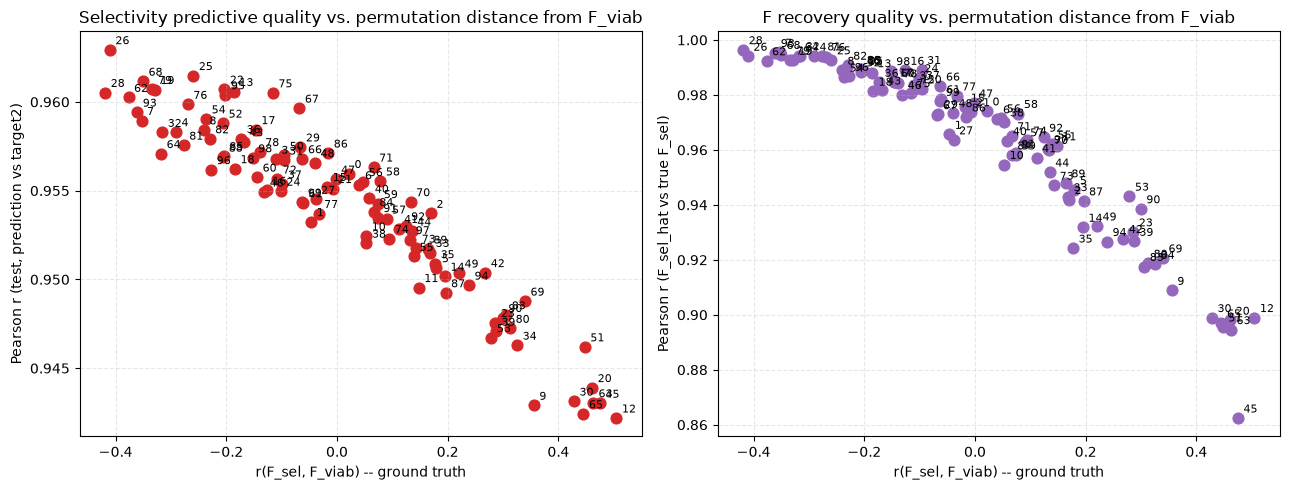

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["r_test_selectivity"], s=60, color="tab:red")
for _, row in results_df.iterrows():
    ax.annotate(str(int(row["perm_idx"])), (row["r_gt_Fsel_vs_Fviab"], row["r_test_selectivity"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("r(F_sel, F_viab) -- ground truth")
ax.set_ylabel("Pearson r (test, prediction vs target2)")
ax.set_title("Selectivity predictive quality vs. permutation distance from F_viab")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["r_recovery_Fsel"], s=60, color="tab:purple")
for _, row in results_df.iterrows():
    ax.annotate(str(int(row["perm_idx"])), (row["r_gt_Fsel_vs_Fviab"], row["r_recovery_Fsel"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("r(F_sel, F_viab) -- ground truth")
ax.set_ylabel("Pearson r (F_sel_hat vs true F_sel)")
ax.set_title("F recovery quality vs. permutation distance from F_viab")
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which population is this?</b><br>
Every "test" correlation in this notebook (<code>r_test_selectivity</code> above, and both scatter plots) is computed on the SAME held-out <code>X_test</code>/<code>idx_test</code> split of the fixed 20,000-sequence random pool (<code>sequences</code>, section 3) -- a 50% random half, ~10,000 sequences, never seen by any of the 30 <code>ProfileMLP</code> models during training. It is not a brute-force search over the full 20^7 combinatorial space, and not the real AAV9 NGS library -- only <code>F_viab</code> (the additive viability ground truth) comes from real AAV9 data here; every sequence actually scored in this notebook is synthetic, and <code>F_sel</code> is a permutation of <code>F_viab</code>, not an independent measurement.
</div>


## 9. Visual check: permutation closest to, and furthest from, `F_viab`

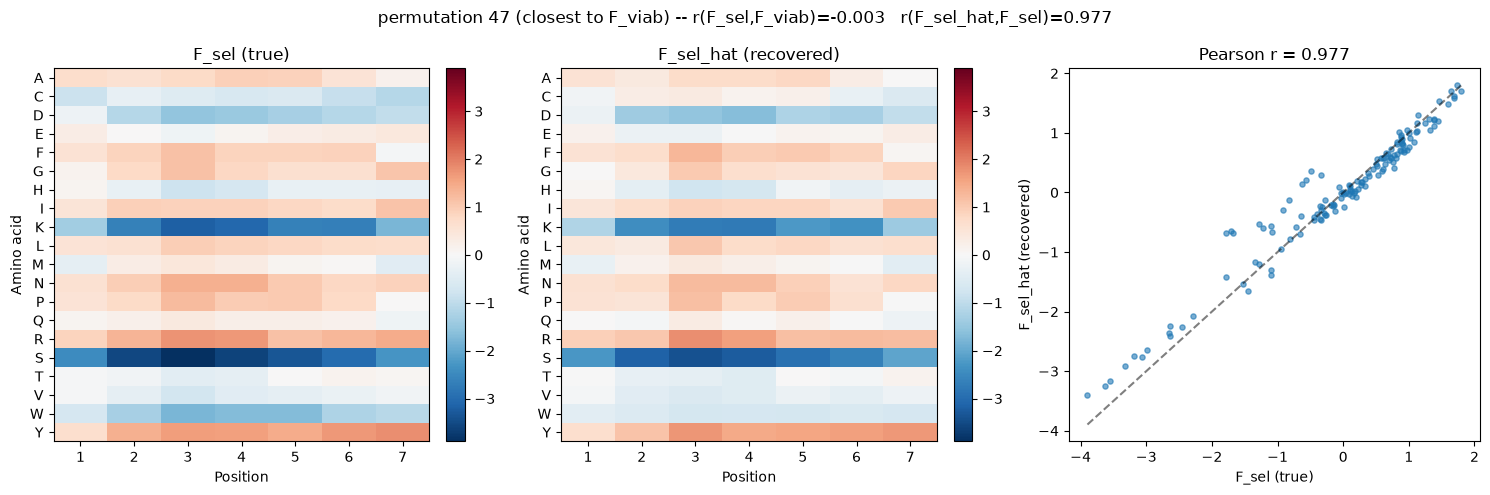

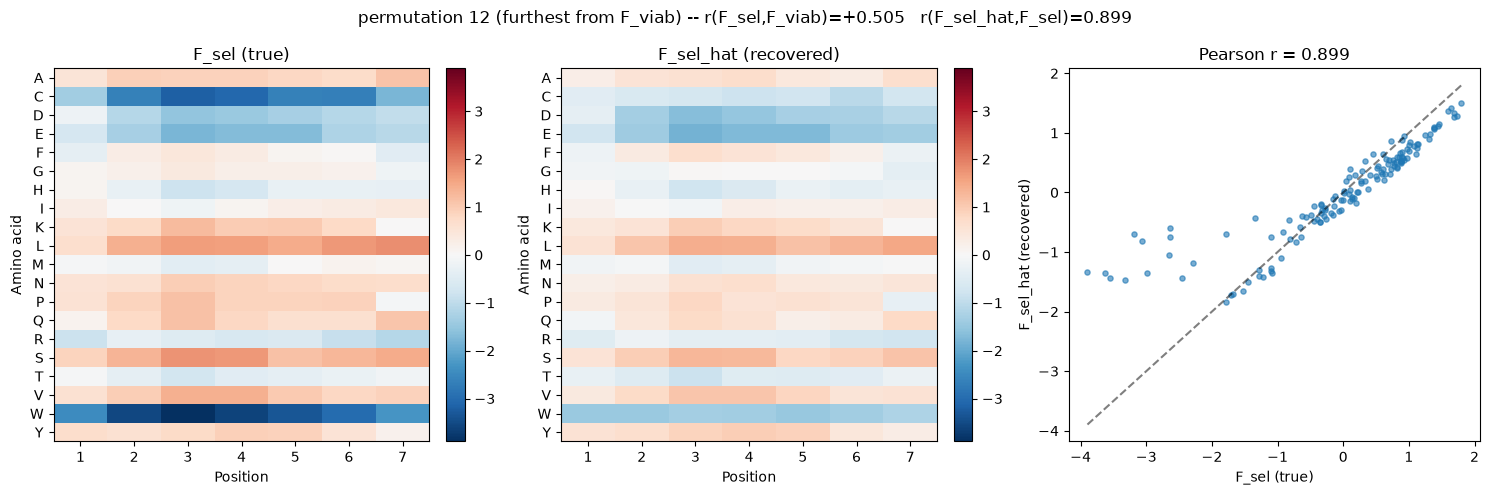

In [66]:
def compare_F(F_a, F_b, title, label_a="F_sel (true)", label_b="F_sel_hat (recovered)"):
    """Same 3-panel recipe as the sibling notebooks: two heatmaps (shared RdBu_r scale) + a
    raw-entry scatter with Pearson r."""
    F_a, F_b = np.asarray(F_a), np.asarray(F_b)
    vmax = max(np.abs(F_a).max(), np.abs(F_b).max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, F, panel_title in [(axes[0], F_a, label_a), (axes[1], F_b, label_b)]:
        im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(panel_title)
        ax.set_xlabel("Position"); ax.set_ylabel("Amino acid")
        ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
        ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    r = pearson(F_a.ravel(), F_b.ravel())
    axes[2].scatter(F_a.ravel(), F_b.ravel(), s=14, alpha=0.6)
    lims = [min(F_a.min(), F_b.min()), max(F_a.max(), F_b.max())]
    axes[2].plot(lims, lims, "k--", alpha=0.5)
    axes[2].set_xlabel(label_a); axes[2].set_ylabel(label_b)
    axes[2].set_title(f"Pearson r = {r:.3f}")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


idx_closest  = results_df["r_gt_Fsel_vs_Fviab"].abs().idxmin()
idx_furthest = results_df["r_gt_Fsel_vs_Fviab"].abs().idxmax()

for idx, tag in [(idx_closest, "closest to F_viab"), (idx_furthest, "furthest from F_viab")]:
    k = int(results_df.loc[idx, "perm_idx"])
    compare_F(F_sel_list[k], F_sel_hat_by_perm[k],
              f"permutation {k} ({tag}) -- r(F_sel,F_viab)={results_df.loc[idx,'r_gt_Fsel_vs_Fviab']:+.3f}   "
              f"r(F_sel_hat,F_sel)={results_df.loc[idx,'r_recovery_Fsel']:.3f}")


## 10. Is the recovered selectivity matrix biased toward anticorrelation with `F_viab`?

Section 8 showed `r_recovery_Fsel` (how well `F_sel_hat` matches the TRUE `F_sel`) dropping for
permutations that are strongly POSITIVELY correlated with `F_viab`, while staying high for
anticorrelated ones. That alone doesn't say WHY -- this section checks a specific hypothesis:
does the recovery process itself pull the estimate toward anticorrelation with `F_viab`,
regardless of the true regime?

- `r_hat_Fsel_vs_Fviab` = the MLP-recovered `F_sel_hat`'s own correlation with `F_viab` (not with
  the true `F_sel` -- that's `r_recovery_Fsel` from section 7/8). Plotted against the true
  `r_gt_Fsel_vs_Fviab`, points below the `y = x` line mean the recovered matrix is MORE
  anticorrelated with `F_viab` than the ground truth actually is.
- `r_naive_Fsel_vs_Fviab` = the SAME check but on a model-free baseline (`naive_F_from_target`,
  section 7): raw per-(amino acid, position) marginal means of `target2`, no MLP at all. If this
  baseline shows the same downward shift, the bias is already present in the simulated NGS data
  itself -- a plausible mechanism is that `target2 = log((lambda3p + eps) / (lambda2p + eps))`
  uses the SAME `eps=1` pseudocount for every sequence, but `lambda2p` (the denominator) is
  smaller for low-`F_viab` variants (fewer capsids survive to be selected on) -- so the pseudocount
  dominates more for exactly those variants, which can inflate their apparent `target2` and
  manufacture a negative correlation with `F_viab` that has nothing to do with the true `F_sel`
  used to generate the data. If only the MLP-recovered estimate shows the shift (not the naive
  one), the bias would instead be something the MLP's optimization introduces on top of clean
  data.


mean bias, MLP-recovered:  mean(r_hat_Fsel_vs_Fviab - r_gt_Fsel_vs_Fviab)   = -0.2044
mean bias, naive raw-data: mean(r_naive_Fsel_vs_Fviab - r_gt_Fsel_vs_Fviab) = -0.2151
permutations where the MLP-recovered estimate is MORE anticorrelated with F_viab than the truth: 100.0% of 100
permutations where the naive raw-data estimate is MORE anticorrelated with F_viab than the truth: 100.0% of 100


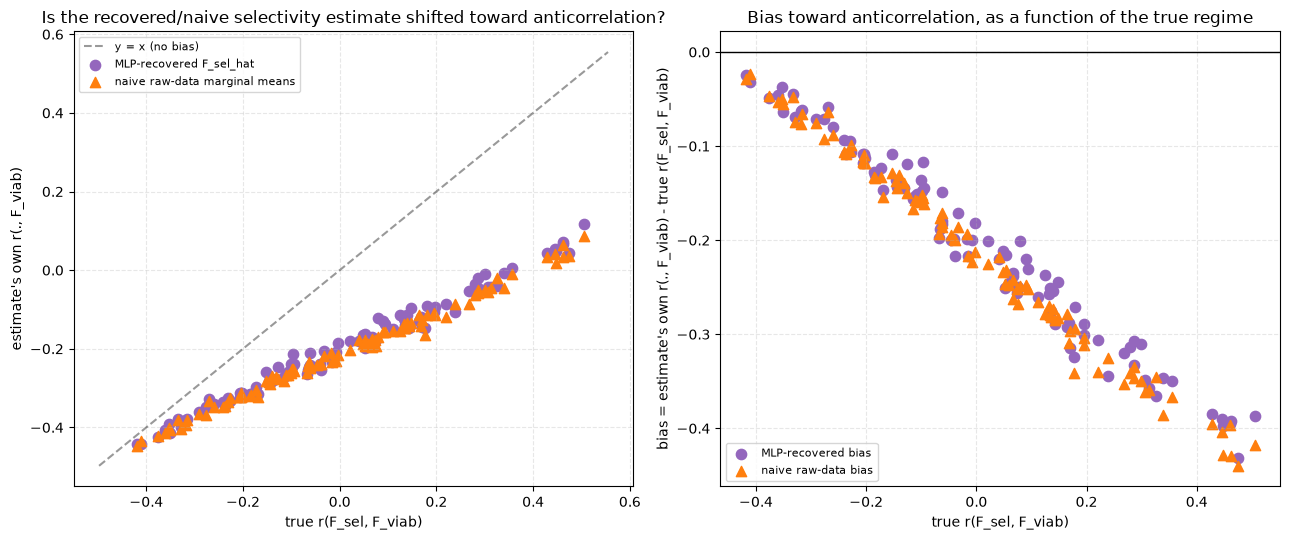

In [67]:
print(f"mean bias, MLP-recovered:  mean(r_hat_Fsel_vs_Fviab - r_gt_Fsel_vs_Fviab)   = "
      f"{results_df['bias_hat_vs_truth'].mean():+.4f}")
print(f"mean bias, naive raw-data: mean(r_naive_Fsel_vs_Fviab - r_gt_Fsel_vs_Fviab) = "
      f"{results_df['bias_naive_vs_truth'].mean():+.4f}")
print(f"permutations where the MLP-recovered estimate is MORE anticorrelated with F_viab than "
      f"the truth: {(results_df['bias_hat_vs_truth'] < 0).mean():.1%} of {N_PERM}")
print(f"permutations where the naive raw-data estimate is MORE anticorrelated with F_viab than "
      f"the truth: {(results_df['bias_naive_vs_truth'] < 0).mean():.1%} of {N_PERM}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
lims = [results_df[["r_gt_Fsel_vs_Fviab", "r_hat_Fsel_vs_Fviab", "r_naive_Fsel_vs_Fviab"]].min().min() - 0.05,
        results_df[["r_gt_Fsel_vs_Fviab", "r_hat_Fsel_vs_Fviab", "r_naive_Fsel_vs_Fviab"]].max().max() + 0.05]
ax.plot(lims, lims, "k--", alpha=0.4, label="y = x (no bias)")
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["r_hat_Fsel_vs_Fviab"],
           s=55, color="tab:purple", label="MLP-recovered F_sel_hat")
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["r_naive_Fsel_vs_Fviab"],
           s=55, color="tab:orange", marker="^", label="naive raw-data marginal means")
ax.set_xlabel("true r(F_sel, F_viab)")
ax.set_ylabel("estimate's own r(., F_viab)")
ax.set_title("Is the recovered/naive selectivity estimate shifted toward anticorrelation?")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.axhline(0, color="black", lw=1)
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["bias_hat_vs_truth"],
           s=55, color="tab:purple", label="MLP-recovered bias")
ax.scatter(results_df["r_gt_Fsel_vs_Fviab"], results_df["bias_naive_vs_truth"],
           s=55, color="tab:orange", marker="^", label="naive raw-data bias")
ax.set_xlabel("true r(F_sel, F_viab)")
ax.set_ylabel("bias = estimate's own r(., F_viab) - true r(F_sel, F_viab)")
ax.set_title("Bias toward anticorrelation, as a function of the true regime")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


## 11. How to read this

- If `r_recovery_Fsel` stays high (close to 1) across every permutation regardless of
  `r_gt_Fsel_vs_Fviab`, the MLP recovers whatever `F_sel` it's given equally well no matter how
  it relates to `F_viab` -- the two phases (viability, selectivity) are cleanly separable from
  `target2` alone, at least in this noise/diversity regime.
- If `r_recovery_Fsel` instead tracks `r_gt_Fsel_vs_Fviab` (e.g. degrading as the permutation
  drifts further from `F_viab`, or vice versa), that would suggest the MLP's ability to isolate
  the selectivity signal depends on how distinguishable `F_sel` is from the co-present `F_viab`
  contribution baked into the same NGS pipeline (viability happens upstream of selectivity in
  `ProtocolV3.N_loop_DE`).
- This is a first pass with `J_viab = J_sel = 0` (pure profile/additive model, no epistasis) --
  extending the same sweep with nonzero `J` (recovering both `F` and `J` via
  `extract_effective_FJ_mlp`, as in `AAV_MLP_weights_recovery.ipynb`) is a natural next step once
  this additive-only picture is understood.
- Section 10's bias check separates two possible explanations for section 8's pattern: if the
  NAIVE (model-free) estimate already drifts toward anticorrelation with `F_viab` at the same
  rate as the MLP-recovered one, the effect traces back to the simulated NGS data itself (the
  `eps` pseudocount / low-`lambda2p` mechanism described there), not to anything specific about
  `ProfileMLP`'s training. If only the MLP-recovered estimate drifts while the naive one doesn't,
  that would point at the model instead.
